In [1]:
import os
from dotenv import load_dotenv
from langchain_groq import ChatGroq
from langchain_huggingface import HuggingFaceEmbeddings

load_dotenv()

db_params = {
    "dbname": "data-sense-db",
    "user": os.getenv("POSTGRES_USERNAME"),
    "password": os.getenv("POSTGRES_PASSWORD"),
    "host": os.getenv("POSTGRES_HOST"),
    "port": "5432",
}
os.environ["HF_TOKEN"] = os.getenv("HF_TOKEN")
embeddings = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")

llm = ChatGroq(
    model="llama-3.3-70b-versatile", api_key=os.getenv("GROQ_API_KEY"), temperature=0
)

llm.invoke("Hello")

d:\ai-learning\data-sense\agent-service\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 8962.75it/s]


AIMessage(content='Hello. How can I help you today?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 10, 'prompt_tokens': 36, 'total_tokens': 46, 'completion_time': 0.025140793, 'completion_tokens_details': None, 'prompt_time': 0.001719287, 'prompt_tokens_details': None, 'queue_time': 0.059058313, 'total_time': 0.02686008}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e6818-df4e-7d72-8182-31d69b852506-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 36, 'output_tokens': 10, 'total_tokens': 46})

In [2]:
import psycopg2
from langchain_core.prompts import ChatPromptTemplate
from pgvector.psycopg2 import register_vector
from collections import defaultdict

In [3]:
def retrieve_relevant_schema(question: str, top_k: int = 5) -> str:
    vec = embeddings.embed_query(question)
    conn = psycopg2.connect(**db_params)
    register_vector(conn)
    cur = conn.cursor()

    RETRIEVAL_SQL = """
        SELECT
            table_name,
            ROUND(
                MAX(
                    (1 - (embedding <=> %s::vector)) *
                    CASE chunk_type
                        WHEN 'use_cases' THEN 1.4
                        WHEN 'overview'  THEN 1.1
                        ELSE                  1.0
                    END
                )::numeric, 4
            ) AS weighted_similarity
        FROM schema_chunks
        GROUP BY table_name
        ORDER BY MAX(
            (1 - (embedding <=> %s::vector)) *
            CASE chunk_type
                WHEN 'use_cases' THEN 1.4
                WHEN 'overview'  THEN 1.1
                ELSE                  1.0
            END
        ) DESC
        LIMIT %s
    """
    cur.execute(RETRIEVAL_SQL, (vec, vec, top_k))
    top_tables = cur.fetchall()

    print("[RAG] Top tables by weighted similarity:")
    for table, score in top_tables:
        print(f"  {table}: {score}")

    table_names = [row[0] for row in top_tables]
    cur.execute(
        """
        SELECT table_name, chunk_type, ddl_chunk
        FROM schema_chunks
        WHERE table_name = ANY(%s)
        ORDER BY table_name, chunk_type
        """,
        (table_names,),
    )
    chunks = cur.fetchall()
    conn.close()

    table_chunks = defaultdict(list)
    for table, chunk_type, ddl_chunk in chunks:
        table_chunks[table].append(f"-- [{chunk_type}]\n{ddl_chunk}")

    return "\n\n".join(
        f"=== {table} ===\n" + "\n\n".join(table_chunks[table])
        for table in table_names  # preserve relevance order
    )


context = retrieve_relevant_schema(
    "Which sellers in Mumbai have stock below reorder level for Fashion products?"
)
print("\n[Full Context]\n")
print(context)

[RAG] Top tables by weighted similarity:
  inventory: 0.7806
  sellers: 0.5251
  products: 0.4841
  orders: 0.4509
  order_items: 0.4492

[Full Context]

=== inventory ===
-- [columns]
TABLE: inventory
COLUMNS:
  inventory_id             character varying -- Unique inventory record identifier (PK)
  product_id               character varying -- FK → products.product_id — which product this stock belongs to
  seller_id                character varying -- FK → sellers.seller_id — which seller holds this stock
  warehouse                character varying -- City name of the fulfillment warehouse holding this stock [values: Mumbai | Delhi | Bengaluru | Hyderabad | Chennai | Kolkata | Pune | Ahmedabad]
  quantity_in_stock        integer -- Current number of units available for sale
  reorder_level            integer -- Stock threshold below which a reorder should be triggered
  reorder_quantity         integer -- Number of units to order when restocking
  last_restocked_at        date -- Da

In [4]:
import pandas as pd


def execute_sql(query: str):
    try:
        conn = psycopg2.connect(**db_params)
        cur = conn.cursor()
        cur.execute(query)
        cols = [d[0] for d in cur.description]
        rows = [dict(zip(cols, row)) for row in cur.fetchall()]
        conn.close()
        return rows, None
    except Exception as e:
        return None, str(e)

In [5]:
SQL_PROMPT = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            """
        Your are an expert PostgreSQL Engineer.
        Given the schema context below, write ONE optimized SQL Query
        that answers the user's question.
        Return only the SQL - no markdown fences, no explaination.
        SCHEMA:
        {schema_context}
        RECENT CONVERSATIONS:
        {conversation_history}
        Rules:
        - Never SELECT *
        - Always alias aggregations: SUM(x) AS total_x
        - Use LIMIT 100 unless user asks for everything
        - Never use INSERT / UPDATE / DELETE / TRUNCATE / DROP
        - Use date_trunc for time grouping
    """,
        ),
        ("human", "Question: {question}"),
    ]
)

In [6]:
sql_generate_chain = SQL_PROMPT | llm

In [47]:
EASY = "How many products are listed in the Electronics category?"
MEDIUM = "What is the total revenue generated by each seller?"
HARD = "Which sellers in Mumbai have stock below reorder level for Fashion products? Give me stock level as well for the sellers"

In [48]:
question = HARD

In [49]:
schema_context = retrieve_relevant_schema(question)
generated_sql = sql_generate_chain.invoke(
    {"question": question, "schema_context": schema_context, "conversation_history": []}
).content.strip()

print(generated_sql)

rows, error = execute_sql(generated_sql)
if error:
    print("SQL Error : ", error)
else:
    df = pd.DataFrame(rows)
    print(f"{len(df)} rows returned")
    print(df)

[RAG] Top tables by weighted similarity:
  inventory: 0.8359
  sellers: 0.5163
  products: 0.4709
  orders: 0.4662
  order_items: 0.4598
SELECT s.seller_id, s.seller_name, i.quantity_in_stock 
FROM inventory i 
JOIN sellers s ON i.seller_id = s.seller_id 
JOIN products p ON i.product_id = p.product_id 
WHERE s.city = 'Mumbai' AND p.category = 'Fashion' AND i.quantity_in_stock < i.reorder_level 
LIMIT 100;
19 rows returned
    seller_id           seller_name  quantity_in_stock
0   SELL00416    Bhatia Enterprises                 55
1   SELL01392     Mumbai Wholesaler                 20
2   SELL01478        Shukla Traders                  8
3   SELL00364        Pillai Traders                 39
4   SELL00756            Prime Zone                 48
5   SELL01346              Shop1881                 73
6   SELL01830              Shop2290                 25
7   SELL00059      Krishnan Traders                 58
8   SELL01347  Krishnan Enterprises                 11
9   SELL01460         Na

In [50]:
INSIGHT_PROMPT = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            """
        You are a business analyst.
        Summarise the query results in 2-3 sentences of plain English.
        Be specific - mention actual numbers and trends from the data.
        Rules:
        - If the price or cost part is involved in the insights, the currency should be INR.
    """,
        ),
        ("human", "Questions: {question}\nResults: {sql_results}"),
    ]
)

insight_chain = INSIGHT_PROMPT | llm

In [51]:
insight_chain.invoke({"question": question, "sql_results": str(rows)}).content

'In Mumbai, 17 sellers have stock levels below the reorder level for Fashion products. The sellers with the lowest stock levels are Pathak Enterprises with 2 units, Krishnan Enterprises and Bansal Enterprises with 8 units, and Kumar Traders with 13 units. The average stock level among these sellers is around 29 units, with the highest being 73 units for Shop1881 and Smart Zone, and the lowest being 2 units for Pathak Enterprises, with no specific price or cost involved in this query.'

In [52]:
VIZ_PROMPT = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            """Write a Matplotlib Python snippet to visualise the data. Assume the data is already in a pandas DataFrame called `df`.

            RULES: 
            - No ```python fences
            - No ``` backticks of any kind
            - No explanation or comments
            - First line must start with 'import' or 'fig'

            FIGURE SIZE RULES — calculate dynamically based on data:
            - For bar charts: width = max(10, len(df) * 0.8), height = 6
            - For horizontal bar charts: width = 10, height = max(6, len(df) * 0.5)
            - For line charts: width = max(10, len(df) * 0.4), height = 6
            - If number of rows > 15, ALWAYS prefer horizontal bar chart (barh) over vertical bar
            - If any label length > 10 characters, ALWAYS use horizontal bar chart (barh)

            LABEL RULES:
            - For vertical bar: rotate x labels using EXACTLY these two lines:
                ax.tick_params(axis='x', rotation=45)
                plt.setp(ax.get_xticklabels(), ha='right')
            - For horizontal bar: no rotation needed, labels are on y axis
            - Always use ax.set_xlabel() and ax.set_ylabel()
            - Always set a title with ax.set_title(fontsize=14)
            - Add value annotations on each bar:
                - Vertical bar: ax.bar_label(ax.containers[0], fmt='%.1f', padding=3)
                - Horizontal bar: ax.bar_label(ax.containers[0], fmt='%.1f', padding=3)

            SPACING RULES:
            - Always end with plt.tight_layout(pad=2.0)
            - Always end with plt.show()
            - Never use fig.show()""",
        ),
        (
            "human",
            """
                Question: {question}
                Columns available: {columns}
                Number of rows: {num_rows}
                Sample data (first 3 rows): {sample_data}
                Longest label value: {longest_label}
            """,
        ),
    ]
)

viz_chain = VIZ_PROMPT | llm

In [53]:
def get_longest_label(df):
    str_cols = df.select_dtypes(include="object").columns
    if len(str_cols) == 0:
        return 0
    return df[str_cols].apply(lambda col: col.astype(str).str.len().max()).max()


viz_code = viz_chain.invoke({
        "question": question,
        "columns": list(df.columns),
        "num_rows": len(df),
        "sample_data": df.head(3).to_dict(orient="records"),
        "longest_label": get_longest_label(df)
    }).content

print(viz_code)

C:\Users\Prashant\AppData\Local\Temp\ipykernel_27144\277422241.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  str_cols = df.select_dtypes(include="object").columns


import matplotlib.pyplot as plt
import pandas as pd

fig, ax = plt.subplots(figsize=(max(10, len(df) * 0.8), 6))

ax.bar(df['seller_name'], df['quantity_in_stock'])

ax.tick_params(axis='x', rotation=45)
plt.setp(ax.get_xticklabels(), ha='right')

ax.set_xlabel('Seller Name')
ax.set_ylabel('Quantity in Stock')
ax.set_title('Sellers in Mumbai with Stock below Reorder Level for Fashion Products', fontsize=14)

ax.bar_label(ax.containers[0], fmt='%.1f', padding=3)

plt.tight_layout(pad=2.0)
plt.show()


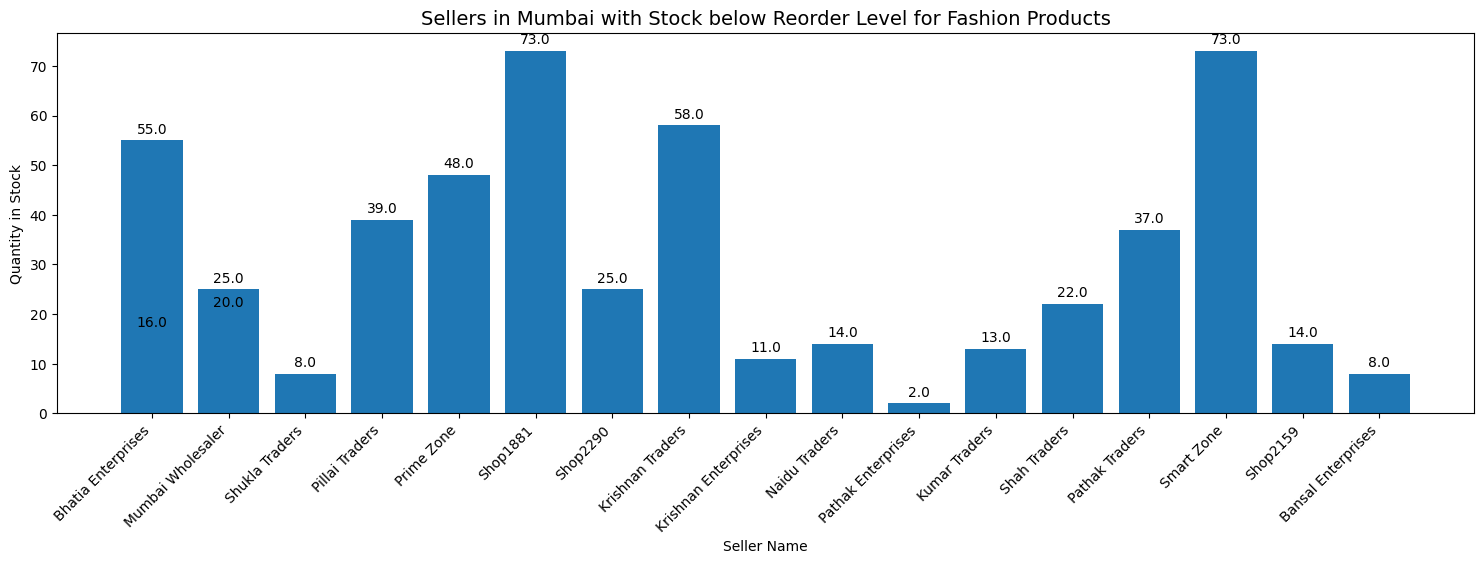

In [54]:
exec(viz_code)

In [55]:
REWRITE_PROMPT = ChatPromptTemplate.from_messages([
    ("system", """You are a PostgreSQL expert debugging a failed query.
Fix the query and return ONLY the corrected SQL. No explanation. No markdown.

SCHEMA CONTEXT:
{schema_context}

FAILED SQL:
{failed_sql}

EXACT DATABASE ERROR:
{db_error}"""),
    ("human", "Original question: {question}"),
])

rewriter_chain = REWRITE_PROMPT | llm

In [58]:
def run_agent(question: str, conversation_history: list = []):
    print(f"\n{'='*50}")
    print(f"Question: {question}")
    print(f"{'='*50}")

    schema_context = retrieve_relevant_schema(question)
    print(f"\n[RAG] Retrieved {len(schema_context)} chars of schema context")

    generated_sql = sql_generate_chain.invoke({
        "question": question,
        "schema_context": schema_context,
        "conversation_history": conversation_history
    }).content.strip()
    print(f"\n[SQL Generated]\n{generated_sql}")

    rows, error = execute_sql(generated_sql)
    if error:
        print(f"\n[SQL Error] {error}")
        print("[Retrying via rewrite...]")
        generated_sql = rewriter_chain.invoke({
            "schema_context": schema_context,
            "failed_sql": generated_sql,
            "db_error": error,
            "question": question
        }).content.strip()
        print(f"\n[Rewritten SQL]\n{generated_sql}")
        rows, error = execute_sql(generated_sql)
    
    if error:
        print(f"\n[Failed after retry] {error}")
        return
    
    df = pd.DataFrame(rows)
    print(f"\n[Result] {len(df)} rows")
    print(df.head())

    insights = insight_chain.invoke({
        "question": question,
        "sql_results": str(rows)
    }).content
    print(f"\n[Insight]\n{insights}")

    viz_code = viz_chain.invoke({
        "question": question,
        "columns": list(df.columns),
        "num_rows": len(df),
        "sample_data": df.head(3).to_dict(orient="records"),
        "longest_label": get_longest_label(df)
    }).content.strip()
    print(f"\n[Viz Code]\n{viz_code}")
    exec(viz_code)


Question: Top 5 customers with details by total orders
[RAG] Top tables by weighted similarity:
  customers: 0.6555
  order_items: 0.6200
  orders: 0.5879
  order_payments: 0.5285
  inventory: 0.5032

[RAG] Retrieved 12249 chars of schema context

[SQL Generated]
SELECT 
    c.customer_id, 
    c.first_name, 
    c.last_name, 
    c.email, 
    COUNT(o.order_id) AS total_orders
FROM 
    customers c
JOIN 
    orders o ON c.customer_id = o.customer_id
GROUP BY 
    c.customer_id, 
    c.first_name, 
    c.last_name, 
    c.email
ORDER BY 
    total_orders DESC
LIMIT 5

[Result] 5 rows
  customer_id first_name last_name                         email  total_orders
0  CUST003626      Rohan    Bansal    rohan.bansal7660@yahoo.com            61
1  CUST007134      Palak    Pandey  palak.pandey4657@outlook.com            59
2  CUST000588     Ishita    Bansal   ishita.bansal2087@gmail.com            58
3  CUST000473     Aditya     Arora    aditya.arora5198@gmail.com            57
4  CUST008074

C:\Users\Prashant\AppData\Local\Temp\ipykernel_27144\277422241.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  str_cols = df.select_dtypes(include="object").columns



[Viz Code]
import matplotlib.pyplot as plt
import pandas as pd

fig, ax = plt.subplots(figsize=(10, max(6, len(df) * 0.5)))

ax.barh(df['first_name'] + ' ' + df['last_name'], df['total_orders'])

ax.set_xlabel('Total Orders')
ax.set_ylabel('Customer Name')
ax.set_title('Top 5 Customers by Total Orders', fontsize=14)

ax.bar_label(ax.containers[0], fmt='%.1f', padding=3)

plt.tight_layout(pad=2.0)
plt.show()


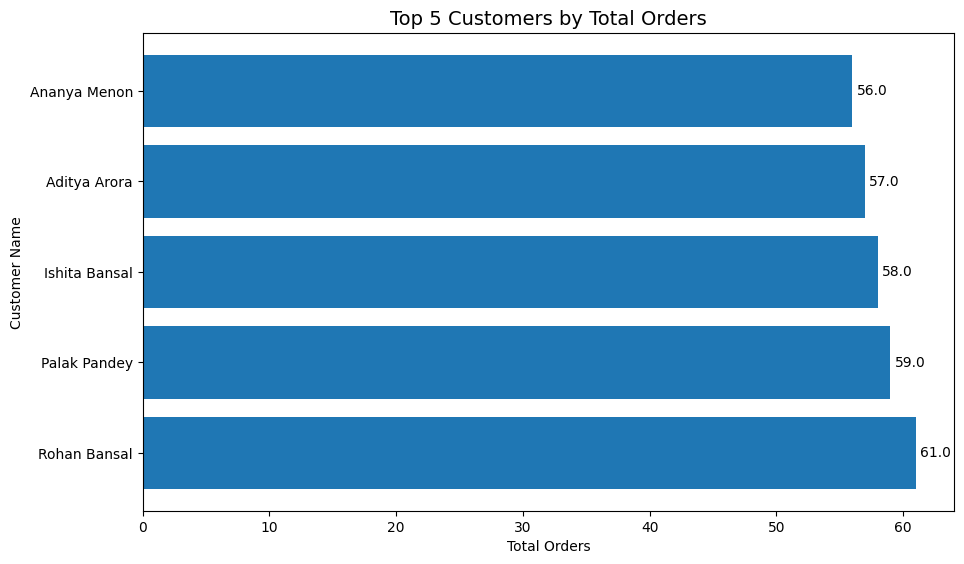

In [60]:
run_agent("Top 5 customers with details by total orders")